# BPL on the web

> Run BPL in a web page, draw BPL's results with JavaScript, and animate pictures

With the npm package `basedpl`, you can run BPL in a web page. It contains BPL's interpreter, compiled to WebAssembly. We built the [playground](playground.qmd) and the [gallery](gallery.qmd) with it.

You don't need the package to draw with JavaScript, animate a picture or animate SVG. All three work in notebooks and Solveit too. The examples in the first three sections are ordinary notebook cells. After those, you'll see how to run BPL in a page of your own, and how we built the gallery.

## Drawing with JavaScript

[`•element`](system/element.qmd) makes an element function for any XML name. When BPL displays a `script` or `style` element as HTML, it leaves the element's text unescaped. Make functions for both, and for a paragraph:

In [ ]:
[script style p]←•element "script" "style" "p"

The browser runs the JavaScript in a `script` element as soon as the element appears on the page. Use one to define `sq`, a global function that draws a red square `d` pixels wide:

In [ ]:
script "function sq(ctx, d) { ctx.fillStyle = 'red'; ctx.fillRect(0, 0, d, d); }"

["tag":"script" "attrs":(⍬:⍬) "children":"function sq(ctx, d) { ctx.fillStyle = 'red'; ctx.fillRect(0, 0, d, d); }"]

The browser applies the CSS in a `style` element to the whole page. Add a rule that colours anything with the class `green` green:

In [ ]:
style ".green { color: green; }"

["tag":"style" "attrs":(⍬:⍬) "children":".green { color: green; }"]

Then give an element that class:

In [ ]:
["class":"green"] p "This paragraph is green."

["tag":"p" "attrs":["class":"green"] "children":"This paragraph is green."]

[`•canvas`](system/canvas.qmd) makes a BPL drawing function from JavaScript source. Because it evaluates the source in the page's global scope, you can pass it the name of a global function, such as `sq`. When the drawing appears, the browser calls your function with the canvas's 2D context and the data from BPL. `sq` takes the data, `50`, as the square's width:

In [ ]:
(•canvas "sq") 50

canvas

Define a second global function, `line`, to draw a line through the rows of an `n×2` matrix of points. You'll draw the rest of this page's pictures with it, through `draw`:

In [ ]:
script "function line(ctx, p) {
  ctx.beginPath();
  for (let i = 0; i < p.data.length; i += 2)
    ctx.lineTo(p.data[i], p.data[i + 1]);
  ctx.stroke();
}"
draw←•canvas "line"

["tag":"script" "attrs":(⍬:⍬) "children":"function line(ctx, p) {
  ctx.beginPath();
  for (let i = 0; i < p.data.length; i += 2)
    ctx.lineTo(p.data[i], p.data[i + 1]);
  ctx.stroke();
}"]

A Lissajous curve is one sine wave plotted against another of a different frequency. Here `x` is the sine of `3t`, and `y` the sine of `2t`. Transposing `[x⋄y]` gives one row per point. Scaling by 140 and 65, and adding 150 and 75, fits the curve to the browser's default canvas of 300 by 150 pixels:

In [ ]:
t←π 2×⍳401 ÷ 400
x←150+140×1○3×t
y←75+65×1○2×t
draw ⍉[x⋄y]

canvas

With complex numbers, you can write a spiral in one line. `○a` is the unit complex number at angle `a`. Multiplying it by `t` makes the radius grow along the curve. `∨` splits each point into the real and imaginary parts that `line` reads as `x` and `y`:

In [ ]:
t←⍳600 ÷ 600
a←π 12×t
draw ∨150ⱼ75+70×t×○a

canvas

## Animating a canvas

You can keep drawing on a canvas for as long as the page is open, if your JavaScript schedules its own next frame. Both loops below stop when their canvas leaves the page, such as when you rerun the cell.

In the first animation, you compute every frame in BPL. `spin` clears the canvas and draws frame `k` with `line`, then schedules frame `k+1` for `1/fps` seconds later. After the last frame, it starts again at the first:

In [ ]:
spin←•canvas "(ctx, frames, o) => {
  let k = 0;
  const tick = () => {
    ctx.clearRect(0, 0, ctx.canvas.width, ctx.canvas.height);
    line(ctx, frames.data[k]);
    k = (k + 1) % frames.data.length;
    if (ctx.canvas.isConnected) setTimeout(tick, 1000 / o.fps);
  };
  tick();
}"

`frame ⍵` gives the Lissajous curve with the phase of `x` shifted by `⍵`. Thirty frames, 12° apart, make one full turn. The last frame then leads straight back into the first:

In [ ]:
t←π 2×⍳101 ÷ 100
y←75+65×1○2×t
frame←{⍉[150+140×1○⍵+3×t⋄y]}
["fps":15] spin frame¨π 2×⍳30 ÷ 30

canvas: 30 frames

In the second animation, the JavaScript makes the frames. You compute a single path in BPL. On each tick, `build` draws `step` more of its points. Once the path is complete, `build` holds the picture for a moment, then starts again from the first point:

In [ ]:
build←•canvas "(ctx, p, o) => {
  let m = 0;
  const tick = () => {
    m = m > 1.5 * p.shape[0] ? 0 : m + o.step;
    ctx.clearRect(0, 0, ctx.canvas.width, ctx.canvas.height);
    line(ctx, {data: p.data.subarray(0, 2 * m)});
    if (ctx.canvas.isConnected) requestAnimationFrame(tick);
  };
  tick();
}"

With a spirograph, you draw the path of a pen held in a wheel that rolls inside a ring. As a complex number, the pen's position is the sum of two circular motions. Here the wheel's centre circles at radius 4. The pen circles that centre at radius 5, in the opposite direction. The path closes after the centre has gone round 7 times:

In [ ]:
t←π 14×⍳2001 ÷ 2000
z←4×○t + 5×○-4×t÷7
["step":10] build ∨150ⱼ75+7.5×z

canvas

BPL stores a drawing's source and all of its data in the output, every frame of an animation included. A few thousand points are fine in a notebook. For more than that, [run BPL in the page](#running-bpl-in-a-page), where your JavaScript reads BPL's arrays straight from memory.

## Animated pictures

[`•image`](system/image.qmd) displays numbers from 0 to 1 as a picture. Given `fps`, it treats the first axis as time and writes the frames as an animated PNG. Use `delay` instead to give each frame its own time on screen. Here `r` holds each pixel's distance from the centre. `phase-⊗r÷3` makes one 64×64 frame of rings for each of the 24 phases:

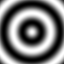

In [ ]:
x←31.5⍈¯31.5
r←√x²+⊗x²
phase←π 2×⍳24 ÷ 24
["fps":12] •image 0.5+0.5×2○phase-⊗r÷3

## Animated SVG

You can animate SVG without any script. Put an `animate` element inside a shape to change one of the shape's attributes over time. Here the browser grows and shrinks the circle's radius, `r`. Make both elements with `•element`:

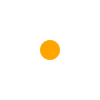

In [ ]:
[circle animate]←•element "circle" "animate"
pulse←["attributeName":"r";"values":"10;40;10";"dur":"2s";"repeatCount":"indefinite"] animate ""
["width":100;"height":100] •svg ["cx":50;"cy":50;"r":10;"fill":"orange"] circle pulse

## Running BPL in a page

Load the package straight from jsDelivr. With the unversioned URL, `https://cdn.jsdelivr.net/npm/basedpl/basedpl_wasm.js`, you get the latest release. Add a version, as in `basedpl@<version>`, to pin one release. Or install the package locally with `npm install basedpl`.

```js
import init, { Session, configure } from 'https://cdn.jsdelivr.net/npm/basedpl/basedpl_wasm.js';

// Fetch the module, which sits beside the glue in the package.
await init();
// Relative file reads resolve against the first argument. The second receives a panic's
// message. After a panic, the module can't run any more code.
configure(location.href, message => console.error(message));
// A session keeps its names from one run to the next.
const session = new Session();
// Each output arrives as it's produced, as {kind, data}. kind is "display" for a displayed
// value, "explicit" for a value assigned to ⎕, or "text" for text written with "-" •nput.
const show = output => console.log(output.data['text/plain']);
// run returns null, or an error object with kind, message and display. display holds the
// error as BPL shows it.
const error = session.run('avg←+/÷≢ ⋄ avg 2 4 9', show);   // logs 5, and error is null
```

`data` maps each MIME type to text, or to a `Uint8Array` for a binary type. See [`•mime`](system/mime.qmd) for the types BPL produces, including the pixel and canvas outputs of the browser build.

`run` blocks until the code finishes. Run long computations in a Web Worker to keep the page responsive. We run BPL in a worker in both the playground and the gallery. Run quick code on the main thread instead, where the JavaScript functions that BPL calls can reach the DOM.

## Values and JavaScript functions

`session.eval(code)` returns the value of `code` to JavaScript. It returns `undefined` when the code gives no value. If the code fails, it throws the BPL error object.

`session.bind(names)` goes the other way. It turns each property of the object `names` into a BPL name. A JavaScript function becomes a BPL function. Call it as `f Y` to pass `Y`, or as `X f Y` to pass `X` then `Y`.

BPL converts values as the table on the [`•js`](system/js.qmd) page shows:

- Numbers and strings stay as they are.
- A record becomes an object.
- Any other array becomes `{shape, data}`, where `data` is a typed array if every item is a number.

```js
session.bind({ scale: 2, log: x => console.log(x) });
session.eval('scale×1 2 3');   // {shape: [3], data: Float64Array [2, 4, 6]}
session.run('log "hi"', () => {});   // logs "hi"
```

Inside BPL, `•js` makes a BPL function from JavaScript source. Only the browser build has it. Try these lines in the [playground](playground.qmd), where they give `5`:

```bpl
h←•js "Math.hypot"
3 h 4
```

Calls into JavaScript have two limits:

- Calls are synchronous. BPL can't wait for a promise to settle.
- A Web Worker has no DOM. To change the page from a worker, bind a function that posts a message, and act on the message in the page. The bound function can't return a result to BPL.

## How the gallery works

The [gallery](gallery.qmd) runs demos written in BPL and draws their frames with JavaScript. We built it from four files:

1. [`worker.js`](https://github.com/AnswerDotAI/basedpl/blob/main/nbs/playground/worker.js) runs BPL in a Web Worker. It answers `{eval: code}` with the code's value, moving its typed arrays to the page without copying them.
2. [`bpl.js`](https://github.com/AnswerDotAI/basedpl/blob/main/nbs/playground/bpl.js) starts the worker and gives the page `run` and `eval`. It also makes the editor, adds the language bar and shows outputs. We use it in the playground too.
3. [`gallery.js`](https://github.com/AnswerDotAI/basedpl/blob/main/nbs/playground/gallery.js) runs the chosen demo. If the demo defines `frame`, `gallery.js` evaluates the next `frame i` on each animation tick and passes the result to the driver. It takes the frame rate from an `fps` option in the demo's `options` record and gives the driver the rest of that record.
4. [`driver.js`](https://github.com/AnswerDotAI/basedpl/blob/main/nbs/driver.js) draws one frame: a record holding an `image` and `triangles`, `lines` and `points` matrices, with one shape per row. See its header comment for the columns and options.

Any BPL file can be a demo. To animate one, define `frame`, and optionally `options`. In [`orbits.bpl`](https://github.com/AnswerDotAI/basedpl/blob/main/nbs/gallery/orbits.bpl), `frame` gives each dot's position and colour at frame `⍵`.

In your own page, you need only three steps: run the BPL, evaluate a frame on each animation tick, and draw it. Here is a minimal version, with BPL on the page's main thread and the same line-drawing code as `line`:

```js
import init, { Session, configure } from 'https://cdn.jsdelivr.net/npm/basedpl/basedpl_wasm.js';

await init();
configure(location.href, message => console.error(message));
const session = new Session();
session.run('t←⍳600 ÷ 600 ⋄ frame←{a←π 12×t ⋄ ∨150ⱼ75+70×t×○a+⍵÷10}', () => {});
const ctx = document.querySelector('canvas').getContext('2d');
for (let i = 0; ; i++) {
  const p = session.eval(`frame ${i}`);
  ctx.clearRect(0, 0, ctx.canvas.width, ctx.canvas.height);
  ctx.beginPath();
  for (let j = 0; j < p.data.length; j += 2) ctx.lineTo(p.data[j], p.data[j + 1]);
  ctx.stroke();
  await new Promise(requestAnimationFrame);
}
```

Each frame shows the spiral turned a little further. For the gallery, we added a worker, a frame rate and error handling.

## Language bar and highlighting

`lb.js` adds a bar of BPL's glyphs to a page. Click a glyph to type it into the editor you used last. In a textarea marked with `data-bpl`, or a Monaco editor whose language is `bpl`, you can also type a backtick followed by a glyph's name, as in the BPL REPL. `lb.js` and `input.js` are scripts whose value is a function. Give the bar the glyph rows from `symbols()` and the key layout from `layout.json`:

```js
import init, { symbols } from 'https://cdn.jsdelivr.net/npm/basedpl/basedpl_wasm.js';

const text = name => fetch(`https://cdn.jsdelivr.net/npm/basedpl/${name}`).then(r => r.text());
const [lb, input, layout] = await Promise.all(['lb.js', 'input.js', 'layout.json'].map(text));
await init();
(0, eval)(lb)(JSON.parse(symbols()), (0, eval)(input), JSON.parse(layout));
```

`bpl.tmLanguage.json` is a TextMate grammar for BPL, with the scope name `source.bpl`. Use it to highlight BPL code with Shiki, or in any editor that reads TextMate grammars.

## Differences from native BPL

- `•js` exists only in the browser build.
- `•readdir`, `•metadata`, `•copy`, `•rename`, `•remove`, `•mkdir`, `•path` and `•delay` don't exist. `•nput` writes only to `"-"`.
- File reads and `•fetch` are synchronous `XMLHttpRequest`s, relative to the URL you pass to `configure`.
- `•r` uses JavaScript's `RegExp`, with its syntax and replacement templates.
- `•date⁻¹` has no `locale` option.
- Function calls nest at most 380 deep. A deeper call is a `LIMIT` error.